<a href="https://colab.research.google.com/github/bigbang120/liquid-ai-mobile/blob/main/liquidaitraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00         5

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



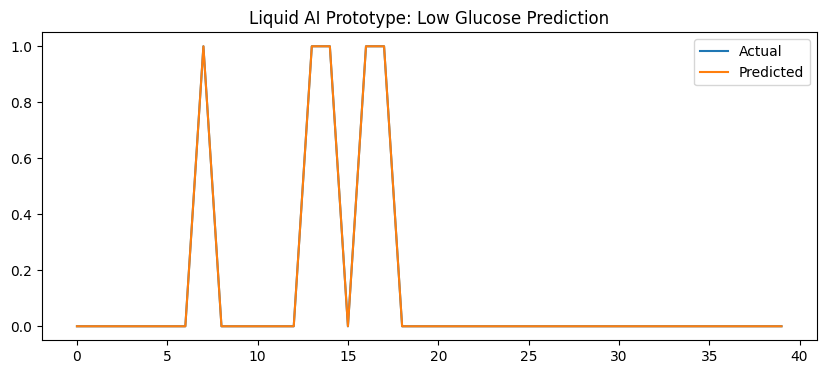

In [1]:
# Step 1: Install libraries
!pip install scikit-learn pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Step 2: Create example dataset (simulating glucose values)
# Later we’ll swap this with a real dataset (like Kaggle/PhysioNet)
import numpy as np
np.random.seed(0)

time = np.arange(0, 200)
glucose = 100 + np.sin(time/10)*15 + np.random.normal(0,3,200)
events = (glucose < 85).astype(int)  # Label "low glucose event"

data = pd.DataFrame({"time": time, "glucose": glucose, "event": events})

# Step 3: Feature engineering
data["slope"] = data["glucose"].diff().fillna(0)
data["rolling_mean"] = data["glucose"].rolling(window=5).mean().fillna(0)

# Step 4: Train/test split
X = data[["glucose", "slope", "rolling_mean"]]
y = data["event"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 5: Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Step 6: Predict
y_pred = model.predict(X_test)

# Step 7: Results
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Liquid AI Prototype: Low Glucose Prediction")
plt.show()
